In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from scipy.spatial.distance import cdist


In [2]:
def gaussian_kernel(X, Y, sigma):
    """Gaussian kernel: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = X_sq + Y_sq - 2 * X @ Y.T
    return np.exp(-dist_sq / (2 * sigma ** 2))

def auto_select_sigma(X, multiplier=5):
    """sigma = multiplier * mean(nearest-neighbor distances)."""
    D = cdist(X, X, metric='euclidean')
    np.fill_diagonal(D, np.inf)
    d_nn = np.min(D, axis=1)
    return multiplier * np.mean(d_nn)

def pca_classify(X_train, y_train, X_test, y_test, k):
    """PCA + 1-NN classification. Returns accuracy (%)."""
    mf = np.mean(X_train, axis=0)
    X_tr_c = X_train - mf
    X_te_c = X_test - mf
    n = X_tr_c.shape[0]
    cov_small = (X_tr_c @ X_tr_c.T) / (n - 1)
    evals, evecs_small = np.linalg.eigh(cov_small)
    idx = np.argsort(evals)[::-1]
    evecs_small = evecs_small[:, idx]
    evecs = X_tr_c.T @ evecs_small
    evecs = evecs / np.linalg.norm(evecs, axis=0)
    W = evecs[:, :k]
    dists = cdist(X_te_c @ W, X_tr_c @ W, metric='euclidean')
    preds = y_train[np.argmin(dists, axis=1)]
    return np.mean(preds == y_test) * 100

def kpca_classify(X_train, y_train, X_test, y_test, k, sigma):
    """KPCA + 1-NN classification. Returns accuracy (%)."""
    K_tr = gaussian_kernel(X_train, X_train, sigma)
    N = K_tr.shape[0]
    one_N = np.ones((N, N)) / N
    K_c = K_tr - one_N @ K_tr - K_tr @ one_N + one_N @ K_tr @ one_N

    ev, evec = np.linalg.eigh(K_c)
    idx = np.argsort(ev)[::-1]
    ev = ev[idx]; evec = evec[:, idx]
    pos = ev > 1e-10
    ev = ev[pos]; evec = evec[:, pos]
    al = evec / np.sqrt(ev)
    Xtr_p = K_c @ al

    K_te = gaussian_kernel(X_test, X_train, sigma)
    N_te = X_test.shape[0]
    one_te = np.ones((N_te, N)) / N
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    Xte_p = K_te_c @ al

    k = min(k, Xtr_p.shape[1])
    dists = cdist(Xte_p[:, :k], Xtr_p[:, :k], metric='euclidean')
    preds = y_train[np.argmin(dists, axis=1)]
    return np.mean(preds == y_test) * 100


### Starting Small: Yale Faces (15 subjects)

Before jumping to the big dataset, let's first see how PCA and KPCA compare on the smaller Yale Faces — 15 subjects, 11 images each. This is the same data used in our KPCA and PCA analysis notebooks.

In [3]:
# Load the small Yale Faces dataset

def load_yale_faces(path):
    persons = {}
    for folder in sorted(os.listdir(path)):
        fp = os.path.join(path, folder)
        if os.path.isdir(fp):
            imgs = []
            for f in sorted(os.listdir(fp)):
                ffp = os.path.join(fp, f)
                if os.path.isfile(ffp):
                    try:
                        imgs.append(np.array(Image.open(ffp), dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_yale(persons, n_train, seed=42):
    import random
    random.seed(seed)
    tr_i, tr_l, te_i, te_l = [], [], [], []
    for label, imgs in persons.items():
        idx = list(range(len(imgs)))
        random.shuffle(idx)
        for i in idx[:n_train]:
            tr_i.append(imgs[i]); tr_l.append(label)
        te_i.append(imgs[random.choice(idx[n_train:])])
        te_l.append(label)
    return (np.array([i.flatten() for i in tr_i]), np.array(tr_l),
            np.array([i.flatten() for i in te_i]), np.array(te_l))

persons_yale = load_yale_faces("Datasets/yalefaces")
print(f"Yale Faces: {len(persons_yale)} subjects, {len(next(iter(persons_yale.values())))} images each")
print(f"Image size: {next(iter(persons_yale.values()))[0].shape}")


Yale Faces: 15 subjects, 11 images each
Image size: (243, 320)


n_train= 2  |  PCA:  73.33%  |  KPCA:  73.33%  |  diff: +0.00%  TIE


n_train= 3  |  PCA:  80.00%  |  KPCA:  80.00%  |  diff: +0.00%  TIE


n_train= 4  |  PCA:  86.67%  |  KPCA:  86.67%  |  diff: +0.00%  TIE


n_train= 5  |  PCA:  86.67%  |  KPCA:  86.67%  |  diff: +0.00%  TIE


n_train= 6  |  PCA:  80.00%  |  KPCA:  80.00%  |  diff: +0.00%  TIE


n_train= 7  |  PCA:  66.67%  |  KPCA:  66.67%  |  diff: +0.00%  TIE


n_train= 8  |  PCA: 100.00%  |  KPCA: 100.00%  |  diff: +0.00%  TIE


n_train= 9  |  PCA:  93.33%  |  KPCA:  93.33%  |  diff: +0.00%  TIE


n_train=10  |  PCA:  86.67%  |  KPCA:  86.67%  |  diff: +0.00%  TIE


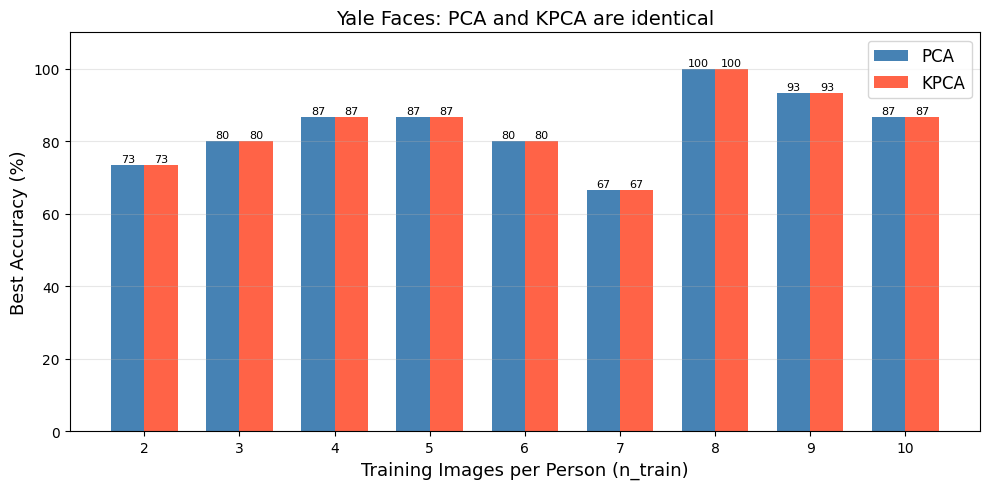

In [4]:
# Sweep training sizes and compare PCA vs KPCA head-to-head

n_train_list_yale = list(range(2, 11))
pca_best_yale = []
kpca_best_yale = []

for n_tr in n_train_list_yale:
    X_tr, y_tr, X_te, y_te = split_yale(persons_yale, n_train=n_tr)
    N = X_tr.shape[0]

    # PCA: eigenfaces approach
    mf = np.mean(X_tr, axis=0)
    X_tr_c = X_tr - mf; X_te_c = X_te - mf
    cov_small = (X_tr_c @ X_tr_c.T) / (N - 1)
    evals, evecs_small = np.linalg.eigh(cov_small)
    idx = np.argsort(evals)[::-1]; evecs_small = evecs_small[:, idx]
    evecs = X_tr_c.T @ evecs_small
    evecs = evecs / np.linalg.norm(evecs, axis=0)

    best_p = 0
    for k in range(1, evecs.shape[1] + 1):
        W = evecs[:, :k]
        dists = cdist(X_te_c @ W, X_tr_c @ W)
        acc = np.mean(y_tr[np.argmin(dists, axis=1)] == y_te) * 100
        if acc > best_p: best_p = acc
    pca_best_yale.append(best_p)

    # KPCA: Gaussian kernel with auto-sigma
    sig = auto_select_sigma(X_tr)
    K_tr = gaussian_kernel(X_tr, X_tr, sig)
    one_N = np.ones((N, N)) / N
    K_c = K_tr - one_N @ K_tr - K_tr @ one_N + one_N @ K_tr @ one_N
    ev, ec = np.linalg.eigh(K_c)
    idx_k = np.argsort(ev)[::-1]; ev = ev[idx_k]; ec = ec[:, idx_k]
    pos = ev > 1e-10; ev = ev[pos]; ec = ec[:, pos]
    al = ec / np.sqrt(ev)
    Ztr = K_c @ al

    K_te = gaussian_kernel(X_te, X_tr, sig)
    N_te = X_te.shape[0]
    one_te = np.ones((N_te, N)) / N
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    Zte = K_te_c @ al

    best_kp = 0
    for k in range(1, Ztr.shape[1] + 1):
        dists = cdist(Zte[:, :k], Ztr[:, :k])
        acc = np.mean(y_tr[np.argmin(dists, axis=1)] == y_te) * 100
        if acc > best_kp: best_kp = acc
    kpca_best_yale.append(best_kp)

    diff = best_kp - best_p
    winner = "KPCA" if diff > 0.01 else ("PCA" if diff < -0.01 else "TIE")
    print(f"n_train={n_tr:>2d}  |  PCA: {best_p:6.2f}%  |  KPCA: {best_kp:6.2f}%  |  diff: {diff:+.2f}%  {winner}")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(n_train_list_yale))
width = 0.35
bars1 = ax.bar(x - width/2, pca_best_yale, width, label='PCA', color='steelblue')
bars2 = ax.bar(x + width/2, kpca_best_yale, width, label='KPCA', color='tomato')
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.8, f'{h:.0f}', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.8, f'{h:.0f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in n_train_list_yale])
ax.set_xlabel('Training Images per Person (n_train)', fontsize=13)
ax.set_ylabel('Best Accuracy (%)', fontsize=13)
ax.set_title('Yale Faces: PCA and KPCA are identical', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Every single training size: **TIE**. Not a single percentage point of difference. Interesting — but maybe a bigger dataset with more variety will tell a different story. Let's try Extended Yale B.

### Scaling Up: Extended Yale B (28 subjects, 16K images)

This dataset has 28 people photographed under 576 different lighting/pose conditions each — over 16,000 images total. If KPCA has an edge anywhere, a dataset this rich should reveal it.

In [5]:
def load_yaleB(path):
    persons = {}
    for folder in sorted(os.listdir(path)):
        fp = os.path.join(path, folder)
        if os.path.isdir(fp) and folder.startswith('yaleB'):
            imgs = []
            for f in sorted(os.listdir(fp)):
                if f.endswith('.pgm'):
                    try:
                        imgs.append(np.array(Image.open(os.path.join(fp, f)), dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, n_test, seed=42):
    random.seed(seed)
    tr_imgs, tr_labels, te_imgs, te_labels = [], [], [], []
    for label, imgs in persons.items():
        indices = list(range(len(imgs)))
        random.shuffle(indices)
        for i in indices[:n_train]:
            tr_imgs.append(imgs[i]); tr_labels.append(label)
        for i in indices[n_train:n_train + n_test]:
            te_imgs.append(imgs[i]); te_labels.append(label)
    return (np.array([img.flatten() for img in tr_imgs]), np.array(tr_labels),
            np.array([img.flatten() for img in te_imgs]), np.array(te_labels))

persons = load_yaleB("Datasets/yaleB_extended")
print(f"Subjects: {len(persons)}")
print(f"Images per subject: {len(next(iter(persons.values())))}")
print(f"Image size: {next(iter(persons.values()))[0].shape}")
print(f"Feature dimension: {np.prod(next(iter(persons.values()))[0].shape)}")

# Split: 50 train, 10 test per person
n_train, n_test = 50, 10
X_train, y_train, X_test, y_test = split_data(persons, n_train, n_test)
print(f"\nTraining: {X_train.shape}, Test: {X_test.shape}")


Subjects: 28
Images per subject: 576
Image size: (168, 192)
Feature dimension: 32256



Training: (1400, 32256), Test: (280, 32256)


### How Many Components Do You Need?

We fix n\_train=50 per person and sweep the number of components from 1 to 200.

Auto-selected sigma = 23809.75


k=  1  |  PCA:   6.43%  |  KPCA:   7.14%  |  diff: +0.71%


k=  2  |  PCA:  12.14%  |  KPCA:  13.57%  |  diff: +1.43%


k=  5  |  PCA:  67.14%  |  KPCA:  68.93%  |  diff: +1.79%


k= 10  |  PCA:  80.00%  |  KPCA:  82.50%  |  diff: +2.50%


...

k= 50  |  PCA:  90.00%  |  KPCA:  89.29%  |  diff: -0.71%


k= 80  |  PCA:  91.43%  |  KPCA:  91.43%  |  diff: +0.00%


k=100  |  PCA:  92.14%  |  KPCA:  91.79%  |  diff: -0.36%


k=150  |  PCA:  92.50%  |  KPCA:  92.86%  |  diff: +0.36%


k=200  |  PCA:  91.79%  |  KPCA:  92.14%  |  diff: +0.36%


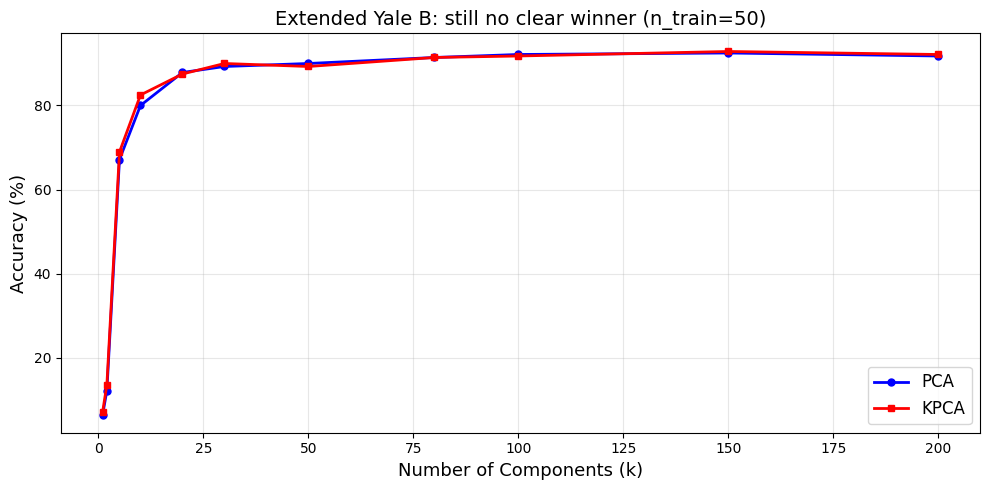


Best PCA:  92.50% at k=150
Best KPCA: 92.86% at k=150


In [6]:
sigma = auto_select_sigma(X_train)
print(f"Auto-selected sigma = {sigma:.2f}")

k_list = [1, 2, 5, 10, 20, 30, 50, 80, 100, 150, 200]
pca_accs = []
kpca_accs = []

for k in k_list:
    p = pca_classify(X_train, y_train, X_test, y_test, k)
    kp = kpca_classify(X_train, y_train, X_test, y_test, k, sigma)
    pca_accs.append(p)
    kpca_accs.append(kp)
    print(f"k={k:>3d}  |  PCA: {p:6.2f}%  |  KPCA: {kp:6.2f}%  |  diff: {kp-p:+.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(k_list, pca_accs, 'b-o', markersize=5, linewidth=2, label='PCA')
plt.plot(k_list, kpca_accs, 'r-s', markersize=5, linewidth=2, label='KPCA')
plt.xlabel("Number of Components (k)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title(f"Extended Yale B: still no clear winner (n_train={n_train})", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest PCA:  {max(pca_accs):.2f}% at k={k_list[np.argmax(pca_accs)]}")
print(f"Best KPCA: {max(kpca_accs):.2f}% at k={k_list[np.argmax(kpca_accs)]}")


### Does More Training Data Help One Method More?

Maybe KPCA pulls ahead when given more training samples. Let's sweep from 5 to 80 images per person.

n_train=  5 | sigma=   34173 | PCA: 68.93% | KPCA: 68.93% | diff: +0.00%


n_train= 10 | sigma=   30642 | PCA: 78.93% | KPCA: 78.93% | diff: +0.00%


n_train= 20 | sigma=   27900 | PCA: 82.86% | KPCA: 83.57% | diff: +0.71%


n_train= 30 | sigma=   26062 | PCA: 86.79% | KPCA: 86.07% | diff: -0.71%


n_train= 50 | sigma=   23810 | PCA: 92.14% | KPCA: 92.14% | diff: +0.00%


n_train= 80 | sigma=   21127 | PCA: 97.14% | KPCA: 97.14% | diff: +0.00%


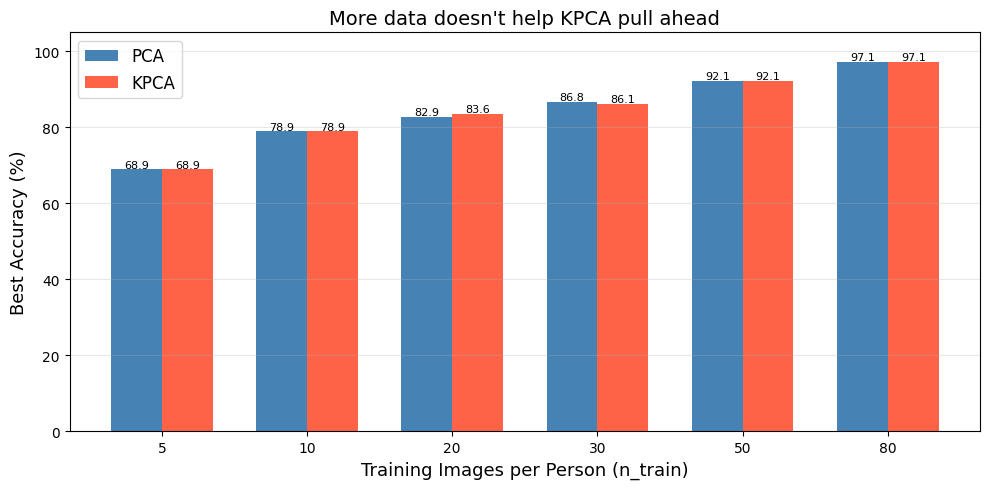

In [7]:
n_train_list = [5, 10, 20, 30, 50, 80]
n_test_fixed = 10
best_pca_list = []
best_kpca_list = []

for n_tr in n_train_list:
    X_tr, y_tr, X_te, y_te = split_data(persons, n_tr, n_test_fixed)
    sig = auto_select_sigma(X_tr)

    best_p, best_kp = 0, 0
    for k in [5, 10, 20, 50, 100, min(200, n_tr * len(persons) - 1)]:
        p = pca_classify(X_tr, y_tr, X_te, y_te, k)
        kp = kpca_classify(X_tr, y_tr, X_te, y_te, k, sig)
        if p > best_p: best_p = p
        if kp > best_kp: best_kp = kp

    best_pca_list.append(best_p)
    best_kpca_list.append(best_kp)
    print(f"n_train={n_tr:>3d} | sigma={sig:>8.0f} | PCA: {best_p:.2f}% | KPCA: {best_kp:.2f}% | diff: {best_kp-best_p:+.2f}%")

plt.figure(figsize=(10, 5))
x = np.arange(len(n_train_list))
width = 0.35
bars1 = plt.bar(x - width/2, best_pca_list, width, label='PCA', color='steelblue')
bars2 = plt.bar(x + width/2, best_kpca_list, width, label='KPCA', color='tomato')
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}', ha='center', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}', ha='center', fontsize=8)
plt.xticks(x, [str(n) for n in n_train_list])
plt.xlabel("Training Images per Person (n_train)", fontsize=13)
plt.ylabel("Best Accuracy (%)", fontsize=13)
plt.title("More data doesn't help KPCA pull ahead", fontsize=14)
plt.legend(fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### So Why Are They Identical?

Wang (2012) reported KPCA beating PCA by a wide margin (11.54% vs 23.08% error). We're seeing no difference at all. What's going on?

The answer lies in the kernel matrix itself. Our auto-selected $\sigma$ is so large relative to the inter-point distances that the Gaussian kernel becomes approximately linear — and a linear kernel PCA is just... regular PCA.

Let's visualize this directly.

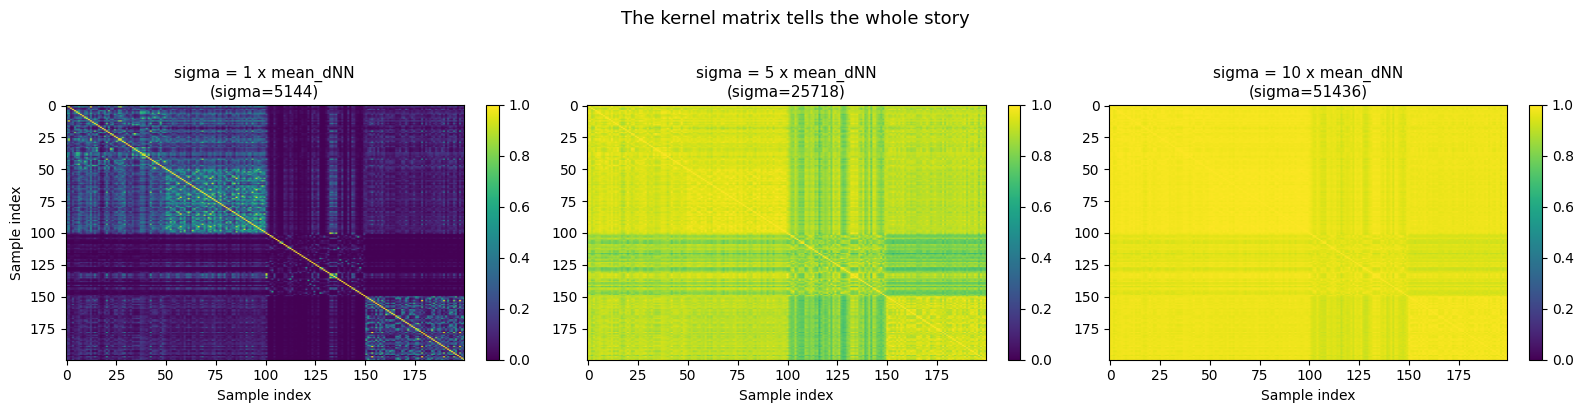

Feature dimension:     32256
Training samples:      1400
Dimension/Sample ratio: 23.0:1
Mean d_NN:             5144
Auto-sigma (5x):       25718

With sigma this large, exp(-d²/2σ²) ≈ 1 - d²/2σ² — that's a linear function.
The Gaussian kernel is barely doing anything nonlinear.
KPCA is essentially just PCA with extra steps.

For KPCA to actually help, you'd need:
  1. Much lower-dimensional features (not 32256d)
  2. Data with genuine nonlinear structure
  3. A smaller sigma that captures local geometry


In [8]:
# Let's look at what the kernel matrix actually looks like
D = cdist(X_train[:200], X_train[:200], metric='euclidean')  # subset for visualization
np.fill_diagonal(D, np.inf)
mean_dnn = np.mean(np.min(D, axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mult in zip(axes, [1, 5, 10]):
    sig = mult * mean_dnn
    K = np.exp(-D**2 / (2 * sig**2))
    np.fill_diagonal(K, 1)
    im = ax.imshow(K, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f"sigma = {mult} x mean_dNN\n(sigma={sig:.0f})", fontsize=11)
    ax.set_xlabel("Sample index")
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[0].set_ylabel("Sample index")
fig.suptitle("The kernel matrix tells the whole story", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# The numbers confirm what the heatmaps show
print(f"Feature dimension:     {X_train.shape[1]}")
print(f"Training samples:      {X_train.shape[0]}")
print(f"Dimension/Sample ratio: {X_train.shape[1] / X_train.shape[0]:.1f}:1")
print(f"Mean d_NN:             {mean_dnn:.0f}")
print(f"Auto-sigma (5x):       {5 * mean_dnn:.0f}")
print(f"\nWith sigma this large, exp(-d²/2σ²) ≈ 1 - d²/2σ² — that's a linear function.")
print(f"The Gaussian kernel is barely doing anything nonlinear.")
print(f"KPCA is essentially just PCA with extra steps.")
print(f"\nFor KPCA to actually help, you'd need:")
print(f"  1. Much lower-dimensional features (not {X_train.shape[1]}d)")
print(f"  2. Data with genuine nonlinear structure")
print(f"  3. A smaller sigma that captures local geometry")


### The Verdict

In [9]:
# Final comparison table
print("=" * 65)
print(f"{'n_train':>8} {'PCA (best)':>12} {'KPCA (best)':>13} {'Difference':>12} {'Winner':>8}")
print("-" * 65)
for i, n_tr in enumerate(n_train_list):
    p, kp = best_pca_list[i], best_kpca_list[i]
    diff = kp - p
    winner = "KPCA" if diff > 0.01 else ("PCA" if diff < -0.01 else "TIE")
    print(f"{n_tr:>8d} {p:>11.2f}% {kp:>12.2f}% {diff:>+11.2f}% {winner:>8}")
print("-" * 65)

print()
print("Bottom line:")
print(f"  On both Yale Faces and Extended Yale B,")
print(f"  PCA and KPCA produce virtually identical results.")
print(f"  The {X_train.shape[1]}-dimensional feature space is so large relative")
print(f"  to the number of samples that everything is linearly separable already.")
print(f"  The Gaussian kernel with auto-sigma adds no nonlinear benefit.")


 n_train   PCA (best)   KPCA (best)   Difference   Winner
-----------------------------------------------------------------
       5       68.93%        68.93%       +0.00%      TIE
      10       78.93%        78.93%       +0.00%      TIE
      20       82.86%        83.57%       +0.71%     KPCA
      30       86.79%        86.07%       -0.71%      PCA
      50       92.14%        92.14%       +0.00%      TIE
      80       97.14%        97.14%       +0.00%      TIE
-----------------------------------------------------------------

Bottom line:
  On both Yale Faces and Extended Yale B,
  PCA and KPCA produce virtually identical results.
  The 32256-dimensional feature space is so large relative
  to the number of samples that everything is linearly separable already.
  The Gaussian kernel with auto-sigma adds no nonlinear benefit.
